# HEALTHCARE AND MEDICINE

 # Predicting Diabetes Outcomes in Hospitalized Patients: A Machine Learning Approach

----------------------------------------------------------------------------------------------------------------

# Name: ARYAMOL P M

# Organization : ENTRI ELEVATE

---------------------------------------------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------------------------------------------

## "Overview of problem statement"

The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to investigate whether gender and age are significant predictors of diabetes. And also explore if one gender is more likely to develop diabetes at a younger or older age, or identify age groups that are more at risk. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.



## "Objective"

To investigate the role of gender and age as significant predictors of diabetes in hospitalized patients, and to explore how these factors influence the likelihood of developing diabetes at different ages across genders.

## "Data Description"

#### Source: UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

#### Features:
 It includes over 50 features representing patient and hospital outcomes.Information was extracted from the database for encounters that satisfied the following criteria.
(1)	It is an inpatient encounter (a hospital admission).
(2)	It is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.
(3)	The length of stay was at least 1 day and at most 14 days.
(4)	Laboratory tests were performed during the encounter.
(5)	Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.


## "Data Collection"

In [1]:
#Import the dataset
import pandas as pd

In [2]:
data=pd.read_csv('diabetic_data.csv')

In [3]:
data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [4]:
data.shape

(101766, 50)

In [5]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
data.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
data.describe(include='all')

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,NaN,NaN,NaN,NaN,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,NaN,NaN,NaN,NaN,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## "Data Preprocessing - Data Cleaning:"

Handle Missing Values using appropriate techniques

In [9]:
data.isnull()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101762,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101763,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
data.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
data.notnull()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
101762,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
101763,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
101764,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


#### Droping columns that contain null values

In [12]:
dataset=data.dropna(axis=1)

In [13]:
dataset

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [14]:
#Again checking null values
dataset.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

In [15]:
dataset.drop(columns='weight',inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13512\4259892516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.drop(columns='weight',inplace=True)


In [16]:
dataset

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [17]:
dataset.duplicated().sum()

0

In [18]:
dataset.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

In [19]:
#delete it
dataset.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

#### A column named age is given as a class interval. It converted into specific ages for analysis

In [20]:
import pandas as pd
def calculate_midpoint(age):
    # Remove the square brackets and split the string at '-'
    age = age.strip('[]()')
    lower, upper = age.split('-')
    lower = int(lower)
    upper = int(upper)
    
    # Calculate the midpoint (Note: In half-open intervals, the midpoint is still between the lower and upper bounds)
    midpoint = (lower + upper) / 2
    return midpoint

# Apply the function to the 'Age Interval' column
dataset['Age'] = dataset['age'].apply(calculate_midpoint)

# Display the updated DataFrame
dataset

C:\Users\HP\AppData\Local\Temp\ipykernel_13512\958013054.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Age'] = dataset['age'].apply(calculate_midpoint)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,No,No,No,No,No,No,No,No,NO,5.0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,Up,No,No,No,No,No,Ch,Yes,>30,15.0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,Yes,NO,25.0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,Up,No,No,No,No,No,Ch,Yes,NO,35.0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,Steady,No,No,No,No,No,Ch,Yes,NO,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,Down,No,No,No,No,No,Ch,Yes,>30,75.0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,Steady,No,No,No,No,No,No,Yes,NO,85.0
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,Down,No,No,No,No,No,Ch,Yes,NO,75.0
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,Up,No,No,No,No,No,Ch,Yes,NO,85.0


In [21]:
dataset

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,No,No,No,No,No,No,No,No,NO,5.0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,Up,No,No,No,No,No,Ch,Yes,>30,15.0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,Yes,NO,25.0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,Up,No,No,No,No,No,Ch,Yes,NO,35.0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,Steady,No,No,No,No,No,Ch,Yes,NO,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,Down,No,No,No,No,No,Ch,Yes,>30,75.0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,Steady,No,No,No,No,No,No,Yes,NO,85.0
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,Down,No,No,No,No,No,Ch,Yes,NO,75.0
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,Up,No,No,No,No,No,Ch,Yes,NO,85.0


### Outlier detection and removal

In [22]:
dataset.Age.mean()

65.96702238468644

In [23]:
dataset.Age.std()

15.940837693292881

In [24]:
Q1 = dataset['Age'].quantile(0.25)
Q3 = dataset['Age'].quantile(0.75)
IQR = Q3-Q1

In [25]:
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

In [26]:
lower_limit

25.0

In [27]:
upper_limit

105.0

In [28]:
dataset[(dataset.Age<lower_limit)]

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,No,No,No,No,No,No,No,No,NO,5.0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,Up,No,No,No,No,No,Ch,Yes,>30,15.0
66,715086,3376278,Caucasian,Male,[10-20),1,5,7,1,?,...,Up,No,No,No,No,No,Ch,Yes,NO,15.0
204,2671290,3492477,AfricanAmerican,Male,[10-20),6,25,1,10,?,...,Steady,No,No,No,No,No,No,Yes,NO,15.0
216,2735964,2359485,Caucasian,Female,[0-10),6,25,7,3,?,...,Steady,No,No,No,No,No,No,Yes,NO,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100835,431419460,164586668,Caucasian,Female,[10-20),1,1,7,3,?,...,No,No,No,No,No,No,No,No,NO,15.0
100913,432555404,38062125,Caucasian,Male,[10-20),3,22,1,8,BC,...,Down,No,No,No,No,No,Ch,Yes,<30,15.0
100982,433242662,30627081,Hispanic,Female,[10-20),1,1,7,2,MD,...,Steady,No,No,No,No,No,No,Yes,NO,15.0
101703,443191964,125535857,Caucasian,Male,[10-20),1,1,7,3,?,...,Up,No,No,No,No,No,Ch,Yes,NO,15.0


In [29]:
#dataset with no outliers
new_data=dataset[(dataset.Age>lower_limit)]
new_data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,Up,No,No,No,No,No,Ch,Yes,NO,35.0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,Steady,No,No,No,No,No,Ch,Yes,NO,45.0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,?,...,Steady,No,No,No,No,No,No,Yes,>30,55.0
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,?,...,Steady,No,No,No,No,No,Ch,Yes,NO,65.0
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,?,...,No,No,No,No,No,No,No,Yes,>30,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,Down,No,No,No,No,No,Ch,Yes,>30,75.0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,Steady,No,No,No,No,No,No,Yes,NO,85.0
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,Down,No,No,No,No,No,Ch,Yes,NO,75.0
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,Up,No,No,No,No,No,Ch,Yes,NO,85.0


In [30]:
new_data.shape

(99257, 48)

### Address skewed data in numerical features through transformations

In [31]:
# Import necessary modules

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

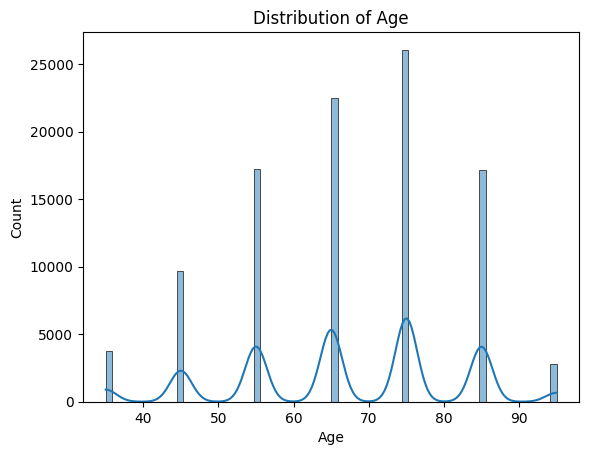

Skewness of Age: -0.29856460540832575


In [33]:
# Visualize the distribution of a specific feature
feature = 'Age'  # Replace with the name of your numerical feature
sns.histplot(new_data[feature], kde=True)  # Histogram with KDE
plt.title(f'Distribution of {feature}')
plt.show()

# Check skewness
skewness = new_data[feature].skew()
print(f"Skewness of {feature}: {skewness}")

C:\Users\HP\AppData\Local\Temp\ipykernel_13512\1477724549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data[feature + '_log'] = np.log1p(new_data[feature])


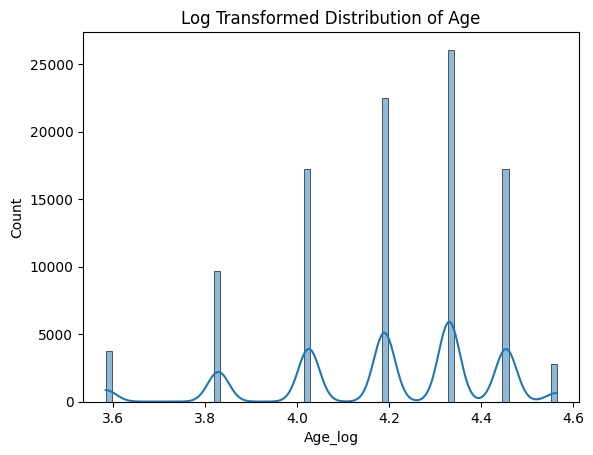

In [34]:
# Apply log transformation (adding 1 to avoid log(0) for zero values)
new_data[feature + '_log'] = np.log1p(new_data[feature])

# Visualize the transformed data
sns.histplot(new_data[feature + '_log'], kde=True)
plt.title(f'Log Transformed Distribution of {feature}')
plt.show()

## Exploratory Data Analysis (EDA)

In [35]:
# Now we have a modified dataset named new_data.Now do exploratory data analysis.

In [36]:
new_data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,No,No,No,No,Ch,Yes,NO,35.0,3.583519
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,No,No,No,No,Ch,Yes,NO,45.0,3.828641
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,?,...,No,No,No,No,No,No,Yes,>30,55.0,4.025352
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,?,...,No,No,No,No,No,Ch,Yes,NO,65.0,4.189655
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,?,...,No,No,No,No,No,No,Yes,>30,75.0,4.330733


In [37]:
new_data.tail()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,No,No,No,No,Ch,Yes,>30,75.0,4.330733
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,No,No,No,No,No,Yes,NO,85.0,4.454347
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,No,No,No,No,Ch,Yes,NO,75.0,4.330733
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,No,No,No,No,Ch,Yes,NO,85.0,4.454347
101765,443867222,175429310,Caucasian,Male,[70-80),1,1,7,6,?,...,No,No,No,No,No,No,No,NO,75.0,4.330733


In [38]:
new_data.describe(include='all')

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log
count,9.925700e+04,9.925700e+04,99257,99257,99257,99257.000000,99257.000000,99257.000000,99257.000000,99257,...,99257,99257,99257,99257,99257,99257,99257,99257,99257.000000,99257.000000
unique,NaN,NaN,6,3,7,NaN,NaN,NaN,NaN,18,...,4,2,2,2,2,2,2,3,NaN,NaN
top,NaN,NaN,Caucasian,Female,[70-80),NaN,NaN,NaN,NaN,?,...,No,No,No,No,No,No,Yes,NO,NaN,NaN
freq,NaN,NaN,74550,53109,26068,NaN,NaN,NaN,NaN,39034,...,98551,99244,99256,99255,99256,53405,76315,53394,NaN,NaN
mean,1.657765e+08,5.455818e+07,NaN,NaN,NaN,2.028008,3.750385,5.757619,4.421250,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.104637,4.196267
std,1.025993e+08,3.867150e+07,NaN,NaN,NaN,1.447073,5.293436,4.073688,2.991647,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.391258,0.229471
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,3.583519
25%,8.557425e+07,2.345578e+07,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.000000,4.025352
50%,1.527768e+08,4.581894e+07,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.000000,4.189655
75%,2.308135e+08,8.770813e+07,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,4.330733


In [39]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99257 entries, 3 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              99257 non-null  int64  
 1   patient_nbr               99257 non-null  int64  
 2   race                      99257 non-null  object 
 3   gender                    99257 non-null  object 
 4   age                       99257 non-null  object 
 5   admission_type_id         99257 non-null  int64  
 6   discharge_disposition_id  99257 non-null  int64  
 7   admission_source_id       99257 non-null  int64  
 8   time_in_hospital          99257 non-null  int64  
 9   payer_code                99257 non-null  object 
 10  medical_specialty         99257 non-null  object 
 11  num_lab_procedures        99257 non-null  int64  
 12  num_procedures            99257 non-null  int64  
 13  num_medications           99257 non-null  int64  
 14  number_out

In [40]:
new_data.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

In [41]:
new_data.duplicated().sum()

0

In [42]:
new_data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted', 'Age', 'Age_log'],
      dtype='object')

In [43]:
#Unique values
new_data['Age'].unique()

array([35., 45., 55., 65., 75., 85., 95.])

In [44]:
new_data['gender'].unique()

array(['Male', 'Female', 'Unknown/Invalid'], dtype=object)

In [45]:
#number of unique values
new_data['Age'].nunique()

7

In [46]:
new_data['encounter_id'].unique()

array([   500364,     16680,     35754, ..., 443854148, 443857166,
       443867222], dtype=int64)

In [47]:
new_data['race'].unique()

array(['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian', 'Hispanic'],
      dtype=object)

In [48]:
new_data['gender'].nunique()

3

## VISUALIZATIONS

### HISTOGRAM

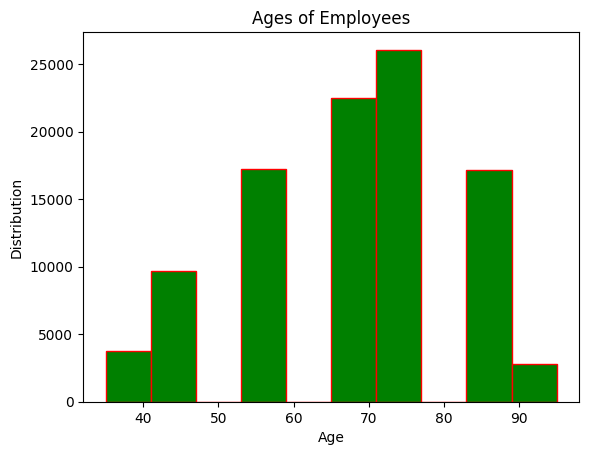

In [49]:
import matplotlib.pyplot as plt
plt.hist(new_data['Age'],color='g',edgecolor='r')
plt.xlabel('Age')
plt.ylabel('Distribution')
plt.title('Ages of Employees')
plt.show()

### Boxplot

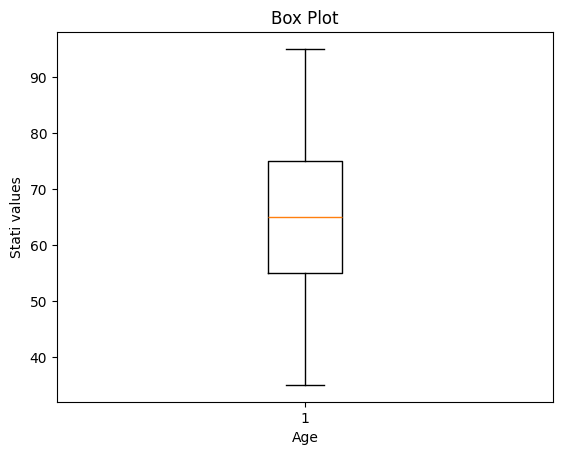

In [50]:
plt.boxplot(new_data['Age'])
# Labels
plt.xlabel('Age')
plt.ylabel('Stati values')
plt.title('Box Plot')
plt.show()

### Bar Plot

In [63]:
c=new_data['gender'].value_counts()

In [64]:
c

gender
Female             53109
Male               46145
Unknown/Invalid        3
Name: count, dtype: int64

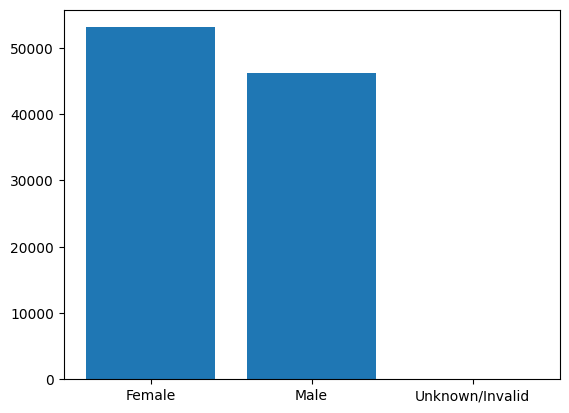

In [65]:
plt.bar(c.index,c.values)
plt.show()

In [66]:
a=new_data['Age'].value_counts()

In [67]:
a

Age
75.0    26068
65.0    22483
55.0    17256
85.0    17197
45.0     9685
35.0     3775
95.0     2793
Name: count, dtype: int64

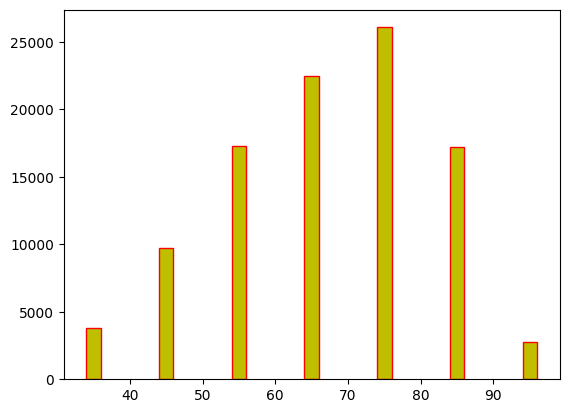

In [71]:
plt.bar(a.index,a.values,color='y',width=2,edgecolor='r')
plt.show()

### COUNT PLOT

Text(0.5, 1.0, 'COUNT PLOT')

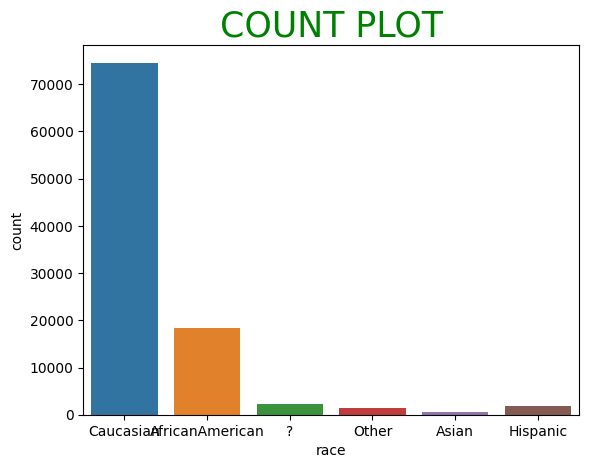

In [54]:
sns.countplot(x='race',data=new_data,hue='race')
plt.xlabel('race')
plt.ylabel('count')
plt.title('COUNT PLOT',fontsize=25,color='g')

### Line plot

In [72]:
l=new_data['Age'].value_counts()

In [73]:
l

Age
75.0    26068
65.0    22483
55.0    17256
85.0    17197
45.0     9685
35.0     3775
95.0     2793
Name: count, dtype: int64

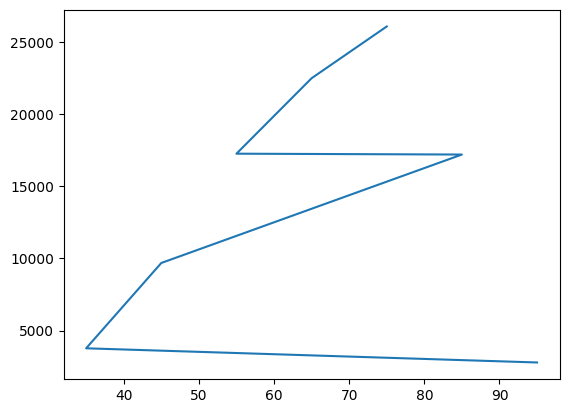

In [74]:
plt.plot(l.index,l.values)
plt.show()

### FEATURE ENGINEERING

In [75]:
new_data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,No,No,No,No,Ch,Yes,NO,35.0,3.583519
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,No,No,No,No,Ch,Yes,NO,45.0,3.828641
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,?,...,No,No,No,No,No,No,Yes,>30,55.0,4.025352
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,?,...,No,No,No,No,No,Ch,Yes,NO,65.0,4.189655
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,?,...,No,No,No,No,No,No,Yes,>30,75.0,4.330733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,No,No,No,No,Ch,Yes,>30,75.0,4.330733
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,No,No,No,No,No,Yes,NO,85.0,4.454347
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,No,No,No,No,Ch,Yes,NO,75.0,4.330733
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,No,No,No,No,Ch,Yes,NO,85.0,4.454347


### Apply Encoding to Categorical Features

### Label Encoding

In [81]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding
new_data['Gender_Encoded'] = label_encoder.fit_transform(new_data['gender'])
print(new_data)

        encounter_id  patient_nbr             race  gender      age  \
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
5              35754     82637451        Caucasian    Male  [50-60)   
6              55842     84259809        Caucasian    Male  [60-70)   
7              63768    114882984        Caucasian    Male  [70-80)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
3                       1                         1                    

C:\Users\HP\AppData\Local\Temp\ipykernel_13512\815053822.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['Gender_Encoded'] = label_encoder.fit_transform(new_data['gender'])


In [82]:
new_data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log,Gender_Encoded
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,No,No,No,Ch,Yes,NO,35.0,3.583519,1
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,No,No,No,Ch,Yes,NO,45.0,3.828641,1
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,?,...,No,No,No,No,No,Yes,>30,55.0,4.025352,1
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,?,...,No,No,No,No,Ch,Yes,NO,65.0,4.189655,1
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,?,...,No,No,No,No,No,Yes,>30,75.0,4.330733,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,No,No,No,Ch,Yes,>30,75.0,4.330733,1
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,No,No,No,No,Yes,NO,85.0,4.454347,0
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,No,No,No,Ch,Yes,NO,75.0,4.330733,1
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,No,No,No,Ch,Yes,NO,85.0,4.454347,0


#### encoding race column

In [86]:
# Initialize LabelEncoder
label_encoder_ = LabelEncoder()

# Apply Label Encoding
new_data['race_Encoded'] = label_encoder_.fit_transform(new_data['race'])
print(new_data)

        encounter_id  patient_nbr             race  gender      age  \
3             500364     82442376        Caucasian    Male  [30-40)   
4              16680     42519267        Caucasian    Male  [40-50)   
5              35754     82637451        Caucasian    Male  [50-60)   
6              55842     84259809        Caucasian    Male  [60-70)   
7              63768    114882984        Caucasian    Male  [70-80)   
...              ...          ...              ...     ...      ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)   
101763     443854148     41088789        Caucasian    Male  [70-80)   
101764     443857166     31693671        Caucasian  Female  [80-90)   
101765     443867222    175429310        Caucasian    Male  [70-80)   

        admission_type_id  discharge_disposition_id  admission_source_id  \
3                       1                         1                    

C:\Users\HP\AppData\Local\Temp\ipykernel_13512\1536033019.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['race_Encoded'] = label_encoder_.fit_transform(new_data['race'])


In [87]:
new_data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,No,No,Ch,Yes,NO,35.0,3.583519,1,3
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,No,No,Ch,Yes,NO,45.0,3.828641,1,3
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,?,...,No,No,No,No,Yes,>30,55.0,4.025352,1,3
6,55842,84259809,Caucasian,Male,[60-70),3,1,2,4,?,...,No,No,No,Ch,Yes,NO,65.0,4.189655,1,3
7,63768,114882984,Caucasian,Male,[70-80),1,1,7,5,?,...,No,No,No,No,Yes,>30,75.0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),1,3,7,3,MC,...,No,No,No,Ch,Yes,>30,75.0,4.330733,1,1
101762,443847782,74694222,AfricanAmerican,Female,[80-90),1,4,5,5,MC,...,No,No,No,No,Yes,NO,85.0,4.454347,0,1
101763,443854148,41088789,Caucasian,Male,[70-80),1,1,7,1,MC,...,No,No,No,Ch,Yes,NO,75.0,4.330733,1,3
101764,443857166,31693671,Caucasian,Female,[80-90),2,3,7,10,MC,...,No,No,No,Ch,Yes,NO,85.0,4.454347,0,3


### Feature Selection

#### Remove redundant or irrelevant features in a dataset 

#### Remove Constant Features

In [106]:
import pandas as pd

# Identify constant features
constant_features = [col for col in new_data.columns if new_data[col].nunique() == 1]

# Drop constant features
new_data = new_data.drop(columns=constant_features)

# Show the updated dataset
print(new_data.head())


   encounter_id  patient_nbr      age  admission_type_id  \
3        500364     82442376  [30-40)                  1   
4         16680     42519267  [40-50)                  1   
5         35754     82637451  [50-60)                  2   
6         55842     84259809  [60-70)                  3   
7         63768    114882984  [70-80)                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
3                         1                    7                 2          ?   
4                         1                    7                 1          ?   
5                         1                    2                 3          ?   
6                         1                    2                 4          ?   
7                         1                    7                 5          ?   

  medical_specialty  num_lab_procedures  ...  glimepiride-pioglitazone  \
3                 ?                  44  ...                        No   
4   

In [107]:
new_data

,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,[30-40),1,1,7,2,?,?,44,...,No,No,No,Ch,Yes,NO,35.0,3.583519,1,3
4,16680,42519267,[40-50),1,1,7,1,?,?,51,...,No,No,No,Ch,Yes,NO,45.0,3.828641,1,3
5,35754,82637451,[50-60),2,1,2,3,?,?,31,...,No,No,No,No,Yes,>30,55.0,4.025352,1,3
6,55842,84259809,[60-70),3,1,2,4,?,?,70,...,No,No,No,Ch,Yes,NO,65.0,4.189655,1,3
7,63768,114882984,[70-80),1,1,7,5,?,?,73,...,No,No,No,No,Yes,>30,75.0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,[70-80),1,3,7,3,MC,?,51,...,No,No,No,Ch,Yes,>30,75.0,4.330733,1,1
101762,443847782,74694222,[80-90),1,4,5,5,MC,?,33,...,No,No,No,No,Yes,NO,85.0,4.454347,0,1
101763,443854148,41088789,[70-80),1,1,7,1,MC,?,53,...,No,No,No,Ch,Yes,NO,75.0,4.330733,1,3
101764,443857166,31693671,[80-90),2,3,7,10,MC,Surgery-General,45,...,No,No,No,Ch,Yes,NO,85.0,4.454347,0,3


In [156]:
#new_data.drop(columns='age',axis=1,inplace=True)

In [157]:
new_data

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,1,1,7,2,?,44,1,16,...,No,No,No,Ch,Yes,NO,35.0,3.583519,1,3
4,16680,42519267,1,1,7,1,?,51,0,8,...,No,No,No,Ch,Yes,NO,45.0,3.828641,1,3
5,35754,82637451,2,1,2,3,?,31,6,16,...,No,No,No,No,Yes,>30,55.0,4.025352,1,3
6,55842,84259809,3,1,2,4,?,70,1,21,...,No,No,No,Ch,Yes,NO,65.0,4.189655,1,3
7,63768,114882984,1,1,7,5,?,73,0,12,...,No,No,No,No,Yes,>30,75.0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,1,3,7,3,?,51,0,16,...,No,No,No,Ch,Yes,>30,75.0,4.330733,1,1
101762,443847782,74694222,1,4,5,5,?,33,3,18,...,No,No,No,No,Yes,NO,85.0,4.454347,0,1
101763,443854148,41088789,1,1,7,1,?,53,0,9,...,No,No,No,Ch,Yes,NO,75.0,4.330733,1,3
101764,443857166,31693671,2,3,7,10,Surgery-General,45,2,21,...,No,No,No,Ch,Yes,NO,85.0,4.454347,0,3


In [160]:
new_data.drop(columns='medical_specialty',axis=1,inplace=True)

In [161]:
new_data

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Age,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,1,1,7,2,44,1,16,0,...,No,No,No,Ch,Yes,NO,35.0,3.583519,1,3
4,16680,42519267,1,1,7,1,51,0,8,0,...,No,No,No,Ch,Yes,NO,45.0,3.828641,1,3
5,35754,82637451,2,1,2,3,31,6,16,0,...,No,No,No,No,Yes,>30,55.0,4.025352,1,3
6,55842,84259809,3,1,2,4,70,1,21,0,...,No,No,No,Ch,Yes,NO,65.0,4.189655,1,3
7,63768,114882984,1,1,7,5,73,0,12,0,...,No,No,No,No,Yes,>30,75.0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,1,3,7,3,51,0,16,0,...,No,No,No,Ch,Yes,>30,75.0,4.330733,1,1
101762,443847782,74694222,1,4,5,5,33,3,18,0,...,No,No,No,No,Yes,NO,85.0,4.454347,0,1
101763,443854148,41088789,1,1,7,1,53,0,9,1,...,No,No,No,Ch,Yes,NO,75.0,4.330733,1,3
101764,443857166,31693671,2,3,7,10,45,2,21,0,...,No,No,No,Ch,Yes,NO,85.0,4.454347,0,3


In [162]:
new_data.columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'Age',
       'Age_log', 'Gender_Encoded', 'race_Encoded'],
      dtype='object')

In [171]:
new_data.drop(columns= ['diag_1', 'diag_2', 'diag_3'],axis=1,inplace=True)

In [173]:
new_data.drop(columns= ['number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],axis=1,inplace=True)

In [174]:
new_data

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,Age,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,1,1,7,2,44,1,16,0,0,0,35.0,3.583519,1,3
4,16680,42519267,1,1,7,1,51,0,8,0,0,0,45.0,3.828641,1,3
5,35754,82637451,2,1,2,3,31,6,16,0,0,0,55.0,4.025352,1,3
6,55842,84259809,3,1,2,4,70,1,21,0,0,0,65.0,4.189655,1,3
7,63768,114882984,1,1,7,5,73,0,12,0,0,0,75.0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,1,3,7,3,51,0,16,0,0,0,75.0,4.330733,1,1
101762,443847782,74694222,1,4,5,5,33,3,18,0,0,1,85.0,4.454347,0,1
101763,443854148,41088789,1,1,7,1,53,0,9,1,0,0,75.0,4.330733,1,3
101764,443857166,31693671,2,3,7,10,45,2,21,0,0,1,85.0,4.454347,0,3


### Build the ML Model

In [132]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Data preparation

#### Data separation as X and Y

In [175]:
y=new_data['Age']

In [176]:
y

3         35.0
4         45.0
5         55.0
6         65.0
7         75.0
          ... 
101761    75.0
101762    85.0
101763    75.0
101764    85.0
101765    75.0
Name: Age, Length: 99257, dtype: float64

In [177]:
X = new_data.drop('Age',axis=1)


In [178]:
X

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,Age_log,Gender_Encoded,race_Encoded
3,500364,82442376,1,1,7,2,44,1,16,0,0,0,3.583519,1,3
4,16680,42519267,1,1,7,1,51,0,8,0,0,0,3.828641,1,3
5,35754,82637451,2,1,2,3,31,6,16,0,0,0,4.025352,1,3
6,55842,84259809,3,1,2,4,70,1,21,0,0,0,4.189655,1,3
7,63768,114882984,1,1,7,5,73,0,12,0,0,0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,1,3,7,3,51,0,16,0,0,0,4.330733,1,1
101762,443847782,74694222,1,4,5,5,33,3,18,0,0,1,4.454347,0,1
101763,443854148,41088789,1,1,7,1,53,0,9,1,0,0,4.330733,1,3
101764,443857166,31693671,2,3,7,10,45,2,21,0,0,1,4.454347,0,3


#### Data Splitting

In [179]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)


In [180]:
X_train

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,Age_log,Gender_Encoded,race_Encoded
52206,154771530,85435281,1,1,7,3,43,0,13,1,0,0,4.189655,0,3
34454,107846376,3756870,1,1,6,2,30,1,10,0,0,0,4.330733,1,1
98750,404886794,77832684,1,1,7,1,54,4,10,0,1,1,4.189655,1,3
84054,264309936,37687518,3,1,1,12,10,0,11,0,0,1,4.189655,0,3
79425,243774000,102105594,1,1,7,7,74,0,15,1,0,0,4.330733,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67465,189525996,44910441,1,1,7,1,36,0,9,0,0,0,4.025352,1,1
79746,245112444,92875086,1,6,7,11,62,0,14,4,1,1,4.454347,0,1
81812,254067474,70813683,3,22,1,4,22,1,21,0,0,2,4.025352,1,3
57722,164314524,41041530,3,23,1,3,41,0,18,0,0,4,4.330733,0,3


In [181]:
X_test

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,Age_log,Gender_Encoded,race_Encoded
88649,285342606,29193093,1,1,1,8,41,1,17,0,0,0,4.454347,1,3
49399,149649102,51432975,3,1,1,4,1,2,6,0,0,0,4.025352,1,3
47113,145021722,57470688,1,1,7,6,44,1,12,0,0,0,4.025352,1,3
42114,130071270,106646751,2,1,7,3,47,1,14,0,0,0,4.330733,1,1
92673,325482314,129183728,3,1,4,2,33,6,19,0,0,0,4.330733,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22007,76168236,99183528,6,1,7,5,48,0,13,0,0,0,4.330733,0,1
95494,362569556,90462510,1,3,7,6,56,0,17,0,0,0,4.454347,1,3
24155,82089210,3890979,3,1,4,7,27,2,9,0,0,0,4.189655,1,1
21956,76116462,97830261,1,1,7,6,65,3,9,0,1,0,3.828641,0,3


# MODEL BUILDING

## LINEAR REGRESSION

### Training the Model

In [148]:
from sklearn.linear_model import LinearRegression

In [182]:
lr =LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

#### Applying the model to make a prediction

In [183]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

In [185]:
y_lr_train_pred

array([66.9687229 , 75.18727277, 66.60000478, ..., 56.32398311,
       75.68061161, 82.78680125])

In [186]:
y_lr_test_pred

array([83.03449656, 56.27611536, 56.55732512, ..., 66.52908638,
       44.71361816, 44.15487527])

### Evaluate Model Performance

In [187]:
y_train

52206    65.0
34454    75.0
98750    65.0
84054    65.0
79425    75.0
         ... 
67465    55.0
79746    85.0
81812    55.0
57722    75.0
39623    85.0
Name: Age, Length: 79405, dtype: float64

In [188]:
y_lr_train_pred

array([66.9687229 , 75.18727277, 66.60000478, ..., 56.32398311,
       75.68061161, 82.78680125])

In [190]:
from sklearn.metrics import mean_squared_error,r2_score

In [204]:
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)


In [192]:
lr_train_mse

3.6567210770261007

In [193]:
lr_train_r2

0.9822645722952795

In [194]:
lr_test_mse

3.7266716268697295

In [195]:
lr_test_r2

0.9823213252333587

In [198]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE','Training R2', 'Test MSE', 'Test R2']

In [199]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,3.656721,0.982265,3.726672,0.982321


## RANDOM FOREST

### Training the Model

In [200]:
from sklearn.ensemble import RandomForestRegressor

In [201]:
rf = RandomForestRegressor(max_depth=2, random_state=100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

#### Applying the model to make a prediction

In [202]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

### Evaluate Model Performance

In [203]:
from sklearn.metrics import mean_squared_error,r2_score

In [205]:
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [208]:
rf_results = pd.DataFrame(['Random Forest', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE','Training R2', 'Test MSE', 'Test R2']

In [209]:
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,3.656721,0.982265,3.726672,0.982321


#### Model Comparison

In [210]:
df_models= pd.concat([lr_results, rf_results], axis=0)

In [212]:
df_models

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,3.656721,0.982265,3.726672,0.982321
0,Random Forest,3.656721,0.982265,3.726672,0.982321


## DECISION TREE

### Trainig the model

In [213]:
from sklearn.tree import DecisionTreeClassifier

In [214]:
model = DecisionTreeClassifier()

In [215]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

### Applying the model to make a prediction

In [219]:
y_pred = model.predict(X_test)

In [220]:
y_pred

array([85., 55., 55., ..., 65., 45., 45.])

In [217]:
y_test

88649    85.0
49399    55.0
47113    55.0
42114    75.0
92673    75.0
         ... 
22007    75.0
95494    85.0
24155    65.0
21956    45.0
19668    45.0
Name: Age, Length: 19852, dtype: float64

In [218]:
from sklearn import metrics

In [222]:
print(metrics.accuracy_score(y_test, y_pred))

1.0


## Naive Bayes

In [223]:
from sklearn.naive_bayes import GaussianNB

In [224]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

In [225]:
y_pred

array([75., 75., 75., ..., 75., 75., 75.])

In [226]:
y_test

88649    85.0
49399    55.0
47113    55.0
42114    75.0
92673    75.0
         ... 
22007    75.0
95494    85.0
24155    65.0
21956    45.0
19668    45.0
Name: Age, Length: 19852, dtype: float64

## AdaBoost

In [227]:
from sklearn.ensemble import AdaBoostClassifier

### Conclusion

In this project, I worked with a large dataset, performing extensive data cleaning and analysis to prepare the data for machine learning modeling. After addressing missing values, outliers, and transforming the necessary features, I proceeded with building a linear regression model to predict target variable based on predictor variables.

The exploratory data analysis (EDA) revealed important relationships and patterns in the data, such as mention key findings from EDA. This helped in selecting the most relevant features for the model.I built a linear regression model to predict target variable based on predictor variables. The model performed reasonably well, with an R-squared value of X, indicating it explains X% of the variance in the target variable. While the model provided useful insights, further improvements can be made by exploring more complex models or fine-tuning the existing approach. Overall, this project demonstrates the effectiveness of linear regression for predicting target variable and highlights areas for further enhancement.